### Compilo un MZI con accoppiatore.
**uso una guida SiEpic ed una ideal per lo sfasamento.**

In [2]:
import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns  ## better plots 
import sax  ## dizionario matrice scattering e circuiti
from jax.typing import ArrayLike
from simphony.libraries import siepic, ideal

In [3]:
MZI_COUP, info = sax.circuit(
    netlist={
        "instances": {
            "coupler_in": "coupler",
            "wg_1": "wg_siepic",
            "wg_2": "wg_ideal",
            "coupler_out": "coupler",
        },
        "connections": {
            "coupler_in,port_3": "wg_1,o0",
            "coupler_in,port_4": "wg_2,o0",
            "wg_1,o1": "coupler_out,port_1",
            "wg_2,o1": "coupler_out,port_2",
        },
        "ports": {
            "in0": "coupler_in,port_1",
            "in1": "coupler_in, port_2",
            "out0": "coupler_out,port_3",
            "out1": "coupler_out, port_4",
        },
    },
    models={
        "coupler": siepic.directional_coupler,
        "wg_siepic": siepic.waveguide,
        "wg_ideal": ideal.waveguide,
    }
)

In [4]:
wl = jnp.linspace(1.5, 1.6, 1000)

In [5]:
S = MZI_COUP(wl = wl ,coupler={"coupling_length": 22.5}, wg_1={"length": 296.64}, wg_2={"length": 296.64})

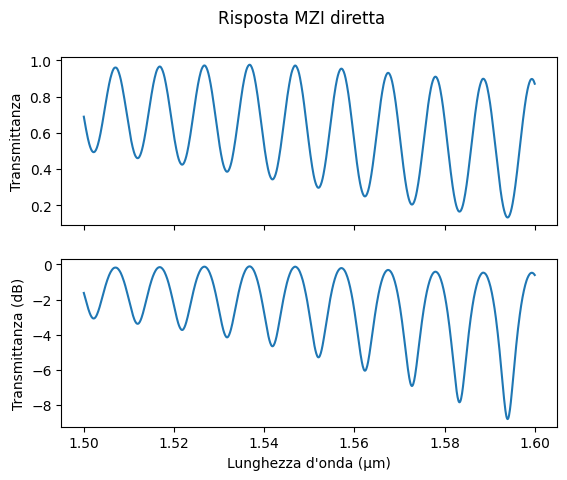

In [6]:
mag1 = jnp.abs(S["out0", "in0"])**2 ##

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag1)
axs[0].set_ylabel("Transmittanza")
axs[1].plot(wl, 10*jnp.log10(mag1))
axs[1].set_ylabel("Transmittanza (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Risposta MZI diretta")
plt.show()

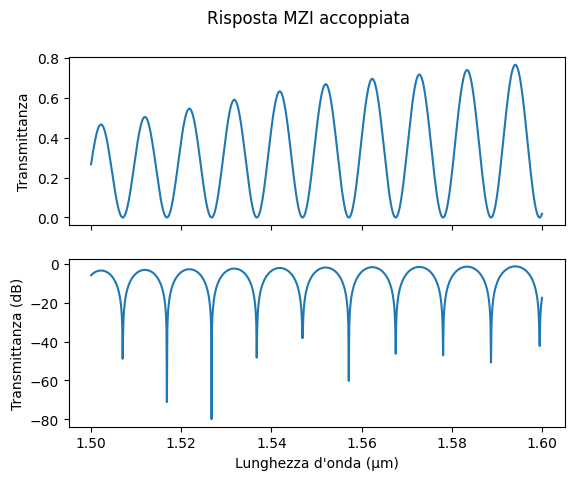

In [7]:
mag2 = jnp.abs(S["out1", "in0"])**2 ##

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag2)
axs[0].set_ylabel("Transmittanza")
axs[1].plot(wl, 10*jnp.log10(mag2))
axs[1].set_ylabel("Transmittanza (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Risposta MZI accoppiata")
plt.show()